Problem Statement

Given a dataset with years of experience and corresponding salary
Use a machine learning model to predict new salary of people based on years of experience

Step 1 - Download required libraries

In [42]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Step 2 - Import required libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

Step 3 - Import the data

In [44]:
ds = pd.read_csv("Salary_dataset.csv")
ds

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


Step 4 - Define X and Y arrays

In [45]:
X = ds["YearsExperience"].values
Y = ds["Salary"].values

In [46]:
X

array([ 1.2,  1.4,  1.6,  2.1,  2.3,  3. ,  3.1,  3.3,  3.3,  3.8,  4. ,
        4.1,  4.1,  4.2,  4.6,  5. ,  5.2,  5.4,  6. ,  6.1,  6.9,  7.2,
        8. ,  8.3,  8.8,  9.1,  9.6,  9.7, 10.4, 10.6])

In [47]:
Y

array([ 39344.,  46206.,  37732.,  43526.,  39892.,  56643.,  60151.,
        54446.,  64446.,  57190.,  63219.,  55795.,  56958.,  57082.,
        61112.,  67939.,  66030.,  83089.,  81364.,  93941.,  91739.,
        98274., 101303., 113813., 109432., 105583., 116970., 112636.,
       122392., 121873.])

Step 5 - Plotting

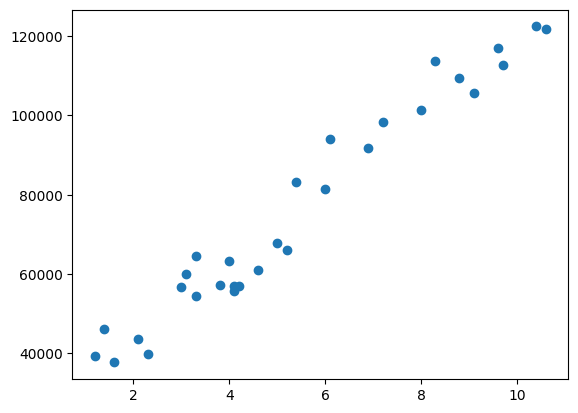

In [48]:
plt.scatter(X,Y)

Observe - Simple straight line can be fitted

Step 6 - Write the loss function

In [49]:
def loss_function(m, b, points):
    total_error = 0

    for i in range(len(points)):
        x = points.iloc[i].YearsExperience
        y = points.iloc[i].Salary

        total_error += (y - (m*x+b))**2
    
    total_error /= 2*float(len(points))

    return total_error

Step 7 - Implement gradient descent

In [50]:
def gradient_descent(m_curr, b_curr, points, L):
    m_grad = 0
    b_grad = 0

    n = len(points)

    for i in range(n):
        x = points.iloc[i].YearsExperience
        y = points.iloc[i].Salary

        m_grad += (1/n) * (m_curr*x + b_curr - y) * x
        b_grad += (1/n) * (m_curr*x + b_curr - y)

    m = m_curr - (L*m_grad)
    b = b_curr - (L*b_grad)

    return m,b


Epoch : 0 | Loss : 3227498696.82
Epoch : 500 | Loss : 140797839.68
Epoch : 1000 | Loss : 70362003.14
Epoch : 1500 | Loss : 67723351.91
Epoch : 2000 | Loss : 66629577.50
Epoch : 2500 | Loss : 65591558.35
Epoch : 3000 | Loss : 64575406.01
Epoch : 3500 | Loss : 63579939.70
Epoch : 4000 | Loss : 62604722.11
Epoch : 4500 | Loss : 61649341.02
12491.548002479107 4124.311137024115


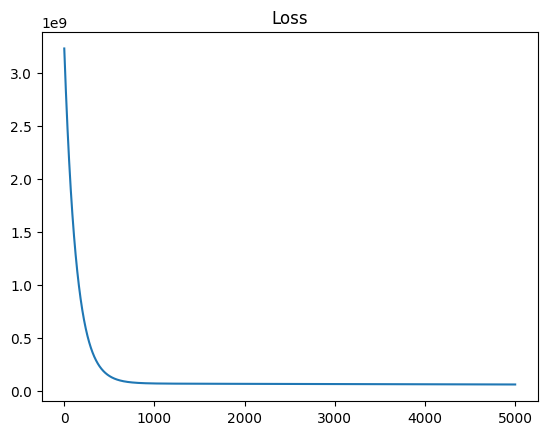

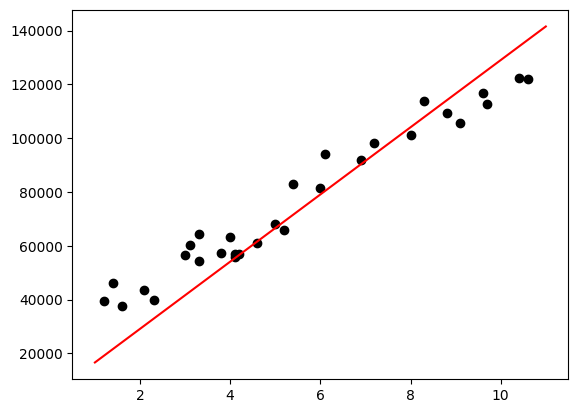

In [54]:
m = 0
b = 0
L = 0.0001
epochs = 5000
losses = []

for i in range(epochs):

    m,b = gradient_descent(m,b,ds,L)
    loss = loss_function(m, b, ds)
    losses.append(loss)

    if i%500 == 0:
        print(f"Epoch : {i} | Loss : {loss:.2f}")

print(m,b)

plt.plot(losses)
plt.title("Loss")
plt.show()

x_line = [i for i in range(1, 12)]
y_line = [m*x + b for x in x_line]

plt.figure()
plt.scatter(ds.YearsExperience, ds.Salary, color="black")
plt.plot(x_line, y_line, color="red")
plt.show()

In [56]:
years = int(input("Enter years of experience: "))
expected_salary = m*years + b

print(f"Expected salary for {years} years of experience: {expected_salary:.2f}")

Expected salary for 5 years of experience: 66582.05
